# **Image Classification Using Deep Features**

### **Libraries**

In [1]:
!pip install --quiet "protobuf<4.25" "tensorflow==2.15.0"
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # hide CUDA factory spam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.6/311.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.24.4 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but

In [2]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from sklearn.pipeline import make_pipeline
from tensorflow.keras.models import Model
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import cv2
import os

2025-11-07 12:46:35.861745: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-07 12:46:35.861873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-07 12:46:35.865112: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### **Configurations**

In [3]:
dataset_dir = "/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse"

train_images, test_images, train_labels, test_labels = [], [], [], []

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_STATE = 42

In [4]:
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(".tif")]
    labels = [class_name] * len(images)

    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3, random_state=42)
    
    train_images.extend(X_train)
    test_images.extend(X_test)
    train_labels.extend(y_train)
    test_labels.extend(y_test)

In [5]:
print(f"train: {len(train_images)} | test: {len(test_images)} | classes: {len(set(train_labels))}")

train: 1470 | test: 630 | classes: 21


In [6]:
# read and preprocess one image path
def load_and_preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise IOError(f"can't read image: {path}")

    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)

    img = cv2.resize(img, IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    return arr  # (1,224,224,3)

In [7]:
sample = train_images[0]
x = load_and_preprocess(sample)
print(f"image path: {sample}")
print(f"Preprocessed shape: {x.shape}")

image path: /kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse/airplane/airplane56.tif
Preprocessed shape: (1, 224, 224, 3)


### **Build VGG16 feature extractor**

In [8]:
base = VGG16(weights="imagenet", include_top=True)
feature_layer_name = "fc2"
feature_extractor = Model(inputs=base.input, outputs=base.get_layer(feature_layer_name).output)

553467096/553467096 [==============================] - 14s 0us/step


In [9]:
feature_extractor.trainable = False
tf.keras.backend.set_learning_phase(0)

/usr/local/lib/python3.11/dist-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [10]:
# batch feature extraction function
def extract_features(paths, batch_size=BATCH_SIZE):
    n = len(paths)
    features = []
    for i in tqdm(range(0, n, batch_size), desc="Extracting features"):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            try:
                arr = load_and_preprocess(p)       
                batch_imgs.append(arr[0])
            except Exception as e:
                # on read failure, replace with zeros and log
                print(f"warning: failed to read {p}: {e}")
                batch_imgs.append(np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.float32))

        batch_array = np.stack(batch_imgs, axis=0)  
        feats = feature_extractor.predict(batch_array, verbose=0)  
        features.append(feats)
    features = np.vstack(features)
    return features

In [11]:
# encode labels to integers 
le = LabelEncoder()
le.fit(train_labels + test_labels) 
y_train = le.transform(train_labels)
y_test  = le.transform(test_labels)
class_names = le.classes_

In [12]:
# extract features
X_train = extract_features(train_images, batch_size=BATCH_SIZE)
X_test  = extract_features(test_images, batch_size=BATCH_SIZE)

Extracting features: 100%|██████████| 20/20 [03:36<00:00, 10.82s/it]


In [13]:
X_train.shape

(1470, 4096)

In [14]:
# train SVM
svm_pipeline = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=20000, random_state=RANDOM_STATE)
)

In [15]:
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(max_iter=20000, random_state=42))])

In [16]:
y_pred = svm_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"test accuracy: {acc:.4f}\n")

test accuracy: 0.9238



In [17]:
print("classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

classification report:
                   precision    recall  f1-score   support

     agricultural     0.9355    0.9667    0.9508        30
         airplane     0.9677    1.0000    0.9836        30
  baseballdiamond     0.9655    0.9333    0.9492        30
            beach     0.9375    1.0000    0.9677        30
        buildings     0.8800    0.7333    0.8000        30
        chaparral     0.9677    1.0000    0.9836        30
 denseresidential     0.7353    0.8333    0.7812        30
           forest     0.9091    1.0000    0.9524        30
          freeway     1.0000    0.9333    0.9655        30
       golfcourse     0.9655    0.9333    0.9492        30
           harbor     0.9677    1.0000    0.9836        30
     intersection     0.9259    0.8333    0.8772        30
mediumresidential     0.8235    0.9333    0.8750        30
   mobilehomepark     0.9643    0.9000    0.9310        30
         overpass     0.9375    1.0000    0.9677        30
       parkinglot     0.9667    

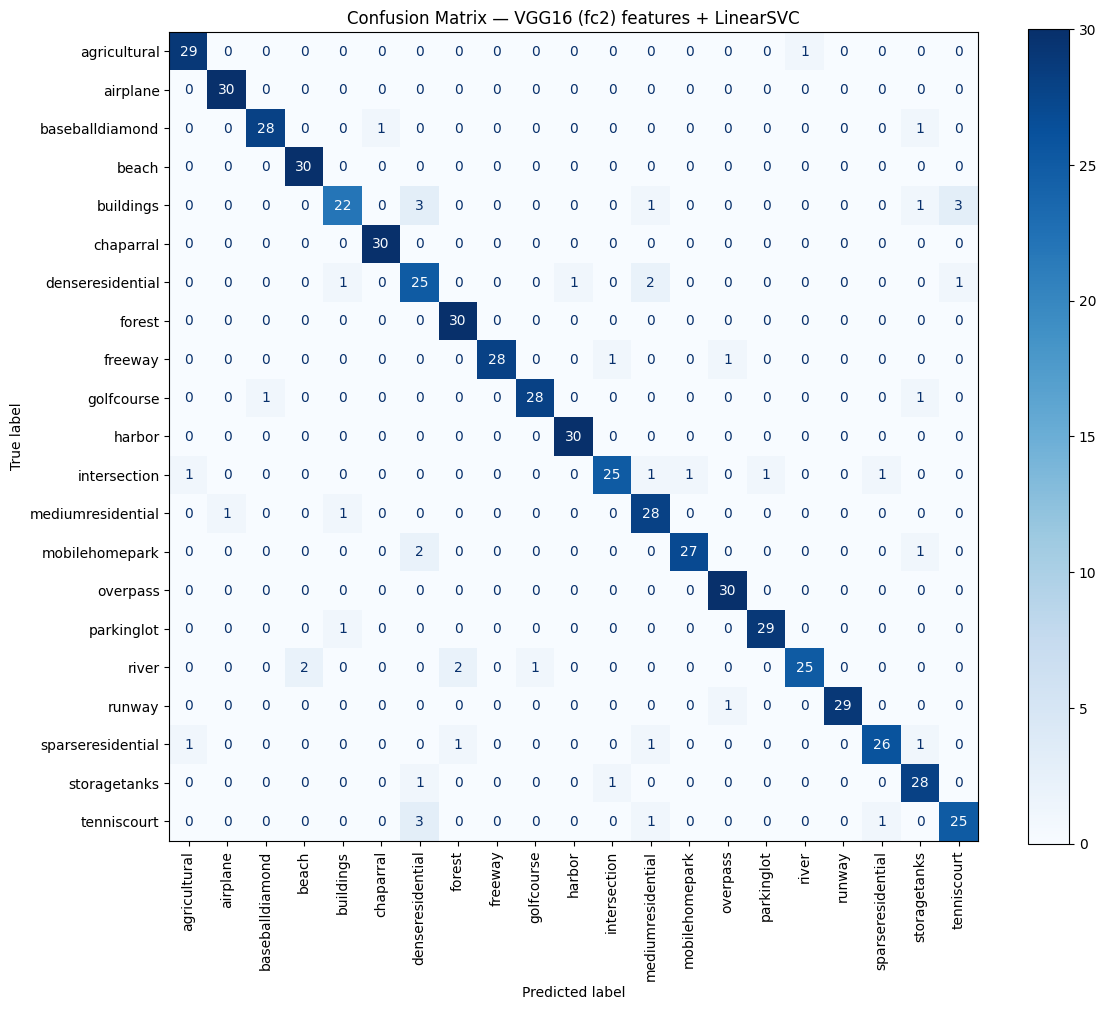

In [18]:
# confusion matrix plot
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90, cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix — VGG16 (fc2) features + LinearSVC")
plt.tight_layout()
plt.show()